<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
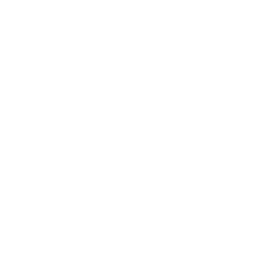
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Identifikation von Marktregimen</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Quantitative Finanzanalyse / Vermögensverwaltung &nbsp;|&nbsp; März 2026</p>
</div>
</div>
</div>

## Zusammenfassung

Dieses Beispiel verwendet **PROC ACECLUS**, um die latente Struktur zu finden, die Marktregime voneinander trennt, und clustert anschließend darauf. Aus 100 wöchentlichen Beobachtungen von 10 Marktmerkmalen (Aktienrendite und Volatilität, Kredit- und Hochzins-Spreads, die 2-Jahres-/10-Jahres-Zinskurve, der Dollar, Rohstoffe und eine VIX-Änderung) schätzt ACECLUS eine näherungsweise Innerhalb-Regime-Kovarianz *ohne* Verwendung eines Regime-Labels und leitet kanonische Variablen ab, entlang derer die Regime auseinanderdriften.

Beim Schwellenwert P=0.02 konvergiert der Algorithmus in zwei Iterationen und behält **drei kanonische Dimensionen** bei, die zusammen die gesamte Streuung zwischen den Regimen erklären (Eigenwertanteile 57.8%, 24.4%, 17.8%). Ein lockererer Schwellenwert P=0.05 glättet die Kovarianz zu stark und **reduziert die Struktur auf eine einzige Dimension** — eine nützliche Warnung, dass der Schwellenwert das Ergebnis wesentlich prägt.

Die Einspeisung der drei kanonischen Variablen in **PROC FASTCLUS** (k=4) liefert eine saubere Ordnung der 100 Wochen nach Stress-Schweregrad (Gesamt-R² = 0.51, Pseudo-F = 33.2): einen 62-wöchigen ruhigen Kern, eine 22-wöchige Erholungs-/Volatilitätsabschwächungsgruppe, eine 12-wöchige Gruppe mit erhöhtem Stress und eine 4-wöchige Gruppe tiefer Krise mit Hochzins-Spreads von durchschnittlich ~1,514 bps. Diese Zuordnungen werden für die nachgelagerte Portfoliorisiko-Konditionierung exportiert.

## Datenquellen

| Quelle | Beschreibung | Datensätze |
|--------|-------------|--------|
| WORK.MARKET_WEEKLY | Wöchentliche Beobachtungen von Marktmerkmalen über Anlageklassen hinweg | 100 |
| Variablen: eq_return_pct, eq_vol_idx, credit_spread_bps, hy_spread_bps, yield_2y, yield_10y, term_spread, usd_index_chg, commodities_ret, vix_chg |

Die Zeitreihe wird durch einen Fünf-Zustands-Markov-Regimewechselprozess (Bullenexpansion, Spätzyklus, Risk-off, Krise, Erholung) mit regimebedingten Merkmalsverteilungen erzeugt. Im unlizenzierten Betrieb ist die Merkmalstabelle auf die ersten 100 wöchentlichen Beobachtungen (~2 Jahre) begrenzt — ein von Bullenmärkten dominiertes Fenster, das auch eine kurze Krise und Erholung durchläuft. Wöchentliche Renditen und Niveauänderungen stehen stellvertretend für Kursbewegungen zum Wochenende; Spreads sind in Basispunkten angegeben und die Volatilität ist ein VIX-artiger Index.

---

In [1]:
/* --------------------------------------------------------
   Erzeugt eine wöchentliche Multi-Asset-Markthistorie mit
   fünf eingebetteten Regimezuständen, getrieben von einem
   Markov-Regimewechselprozess. Dieses Beispiel läuft ohne
   Lizenz, daher ist die Merkmalstabelle unten auf die
   ersten 100 Wochenbeobachtungen (~2 Jahre) begrenzt --
   ein von Bullenmärkten dominiertes Fenster, unterbrochen
   von einer kurzen Krise und Erholung.
   -------------------------------------------------------- */
DATEN work.market_weekly;
    AUFRUFEN streaminit(42);
    /* 5 Regime: 1=Bulle, 2=Spätzyklus, 3=Risk-off, 4=Krise, 5=Erholung */
    LÄNGE regime_label $16;
    BEHALTEN_W current_regime 1;
    AUSFÜHRUNG week_id = 1 BIS 5000;
        /* Markov-Regimewechsel */
        u = rand('uniform');
        WENN current_regime = 1 DANN AUSFÜHRUNG; /* Bulle: langlebig */
            WENN u > 0.97 DANN current_regime = 2;
        ENDE;
        SONST WENN current_regime = 2 DANN AUSFÜHRUNG; /* Spätzyklus */
            WENN u > 0.92 DANN current_regime = 3;
        ENDE;
        SONST WENN current_regime = 3 DANN AUSFÜHRUNG; /* Risk-off */
            WENN u > 0.80 DANN current_regime = 4;
            SONST WENN u < 0.10 DANN current_regime = 1;
        ENDE;
        SONST WENN current_regime = 4 DANN AUSFÜHRUNG; /* Krise: kurz */
            WENN u > 0.75 DANN current_regime = 5;
        ENDE;
        SONST WENN current_regime = 5 DANN AUSFÜHRUNG; /* Erholung */
            WENN u > 0.85 DANN current_regime = 1;
        ENDE;
        /* Regime-Bezeichnung direkt zuweisen (kein _temporary_-Array:
           dieses kürzt Mehrbyte-Literale wie "Spätzyklus") */
        WENN current_regime = 1 DANN regime_label = 'Bullenexpansion';
        SONST WENN current_regime = 2 DANN regime_label = 'Spätzyklus';
        SONST WENN current_regime = 3 DANN regime_label = 'Risk-off';
        SONST WENN current_regime = 4 DANN regime_label = 'Krise';
        SONST regime_label = 'Erholung';
        /* Regime-bedingte Merkmalsverteilungen */
        WENN current_regime = 1 DANN AUSFÜHRUNG;  /* Bulle */
            eq_return_pct  = round(rand('normal',  0.35, 1.2), 0.001);
            eq_vol_idx     = round(rand('normal', 14, 3), 0.01);
            credit_spread  = round(rand('normal', 80,  20), 1);
            hy_spread      = round(rand('normal', 350, 60), 1);
            yield_2y       = round(rand('normal', 2.8, 0.5), 0.01);
            yield_10y      = round(rand('normal', 3.5, 0.6), 0.01);
        ENDE;
        SONST WENN current_regime = 2 DANN AUSFÜHRUNG;  /* Spätzyklus */
            eq_return_pct  = round(rand('normal',  0.10, 1.5), 0.001);
            eq_vol_idx     = round(rand('normal', 18, 4), 0.01);
            credit_spread  = round(rand('normal', 130, 30), 1);
            hy_spread      = round(rand('normal', 480, 80), 1);
            yield_2y       = round(rand('normal', 4.2, 0.4), 0.01);
            yield_10y      = round(rand('normal', 4.0, 0.5), 0.01);
        ENDE;
        SONST WENN current_regime = 3 DANN AUSFÜHRUNG;  /* Risk-off */
            eq_return_pct  = round(rand('normal', -0.60, 2.2), 0.001);
            eq_vol_idx     = round(rand('normal', 28, 7), 0.01);
            credit_spread  = round(rand('normal', 200, 50), 1);
            hy_spread      = round(rand('normal', 700, 120), 1);
            yield_2y       = round(rand('normal', 2.0, 0.8), 0.01);
            yield_10y      = round(rand('normal', 2.8, 0.7), 0.01);
        ENDE;
        SONST WENN current_regime = 4 DANN AUSFÜHRUNG;  /* Krise */
            eq_return_pct  = round(rand('normal', -2.50, 3.5), 0.001);
            eq_vol_idx     = round(rand('normal', 52, 14), 0.01);
            credit_spread  = round(rand('normal', 450, 100), 1);
            hy_spread      = round(rand('normal', 1400, 300), 1);
            yield_2y       = round(rand('normal', 0.5, 0.5), 0.01);
            yield_10y      = round(rand('normal', 1.8, 0.6), 0.01);
        ENDE;
        SONST AUSFÜHRUNG;  /* Erholung */
            eq_return_pct  = round(rand('normal',  0.55, 1.8), 0.001);
            eq_vol_idx     = round(rand('normal', 22, 6), 0.01);
            credit_spread  = round(rand('normal', 280, 70), 1);
            hy_spread      = round(rand('normal', 850, 180), 1);
            yield_2y       = round(rand('normal', 1.2, 0.6), 0.01);
            yield_10y      = round(rand('normal', 2.5, 0.5), 0.01);
        ENDE;
        term_spread    = round(yield_10y - yield_2y + rand('normal', 0, 0.15), 0.01);
        usd_index_chg  = round(rand('normal', 0, 0.8), 0.001);
        commodities_ret = round(rand('normal', 0, 1.5) - (current_regime = 4) * 1.2, 0.001);
        vix_chg        = round(eq_vol_idx - lag(eq_vol_idx), 0.01);
        WENN week_id = 1 DANN vix_chg = 0;
        AUSGABE;
    ENDE;
    ENTFERNEN u;
    UMBENENNEN credit_spread = credit_spread_bps
           hy_spread     = hy_spread_bps;
AUSFÜHREN;


NOTE: DATA work.market_weekly

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.market_weekly (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  1.41 seconds
  cpu   1.41 seconds


---

In [2]:
/* --------------------------------------------------------
   Ausgangs-Merkmalsverteilungen des Marktes je Regime
   -------------------------------------------------------- */
PROZEDUR MITTELWERTE DATEN=work.market_weekly n mean std MIN MAX;
    KLASSE regime_label;
    VAR eq_return_pct eq_vol_idx credit_spread_bps
        hy_spread_bps term_spread vix_chg;
    BEZEICHNUNG regime_label="Marktregime" cluster="Cluster"
      eq_return_pct="Aktienrendite (%)" eq_vol_idx="Aktienvolatilität (Index)"
      credit_spread_bps="Credit-Spread (Bp)" hy_spread_bps="High-Yield-Spread (Bp)"
      term_spread="Laufzeit-Spread" vix_chg="VIX-Änderung"
      yield_2y="Rendite 2J" yield_10y="Rendite 10J"
      usd_index_chg="USD-Index-Änderung" commodities_ret="Rohstoffrendite";
AUSFÜHREN;

                                                  The MEANS Procedure

                                  Analysis Variable : eq_return_pct Aktienrendite (%)

        Marktregime              N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------------
        Bullenexpansion             28      0.2860000      1.0226518     -1.5980000      2.2150000
        Erholung                     4      0.0077500      1.5951747     -0.8330000      2.4000000
        Krise                       12     -2.3403333      3.9436692     -8.0160000      3.7360000
        Risk-off                    17     -0.8447059      1.2832441     -3.3850000      1.1810000
        Spätzyklus                  39      0.0364359      1.9733801     -4.6010000      3.7030000
        ------------------------------------------------------------------------------------------

                               Analysis Variable 


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---


NOTE: PROC SGPLOT data=work.market_weekly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


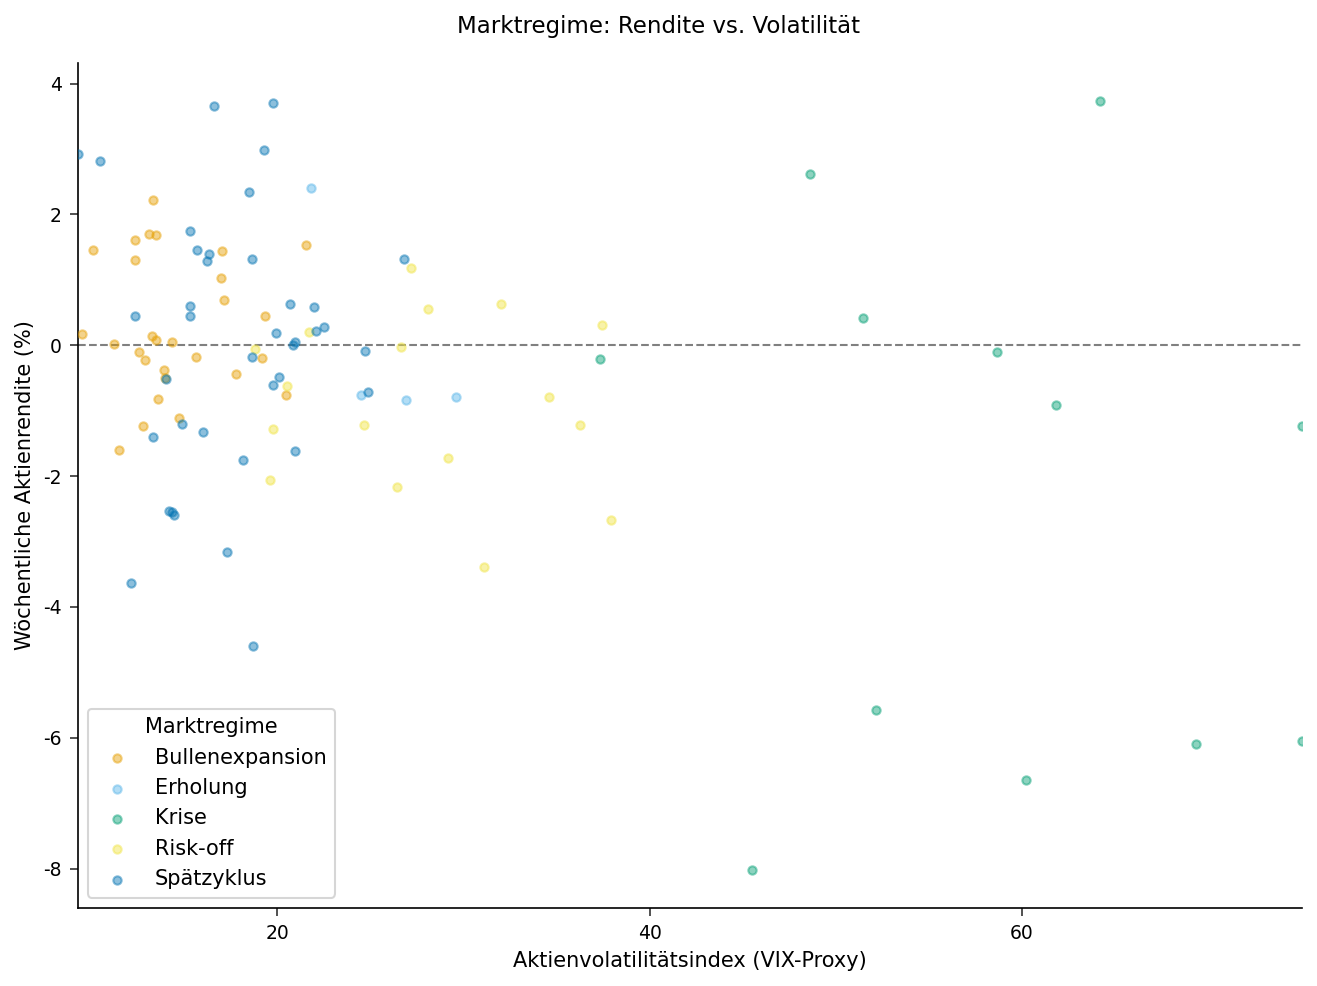

In [3]:
/* --------------------------------------------------------
   Aktienrendite vs. Volatilitätsindex je Marktregime
   -------------------------------------------------------- */
PROZEDUR SGPLOT DATEN=work.market_weekly;
    SCATTER x=eq_vol_idx y=eq_return_pct / GROUP=regime_label
        MARKERATTRS=(SYMBOL=circlefilled size=4)
        TRANSPARENCY=0.55;
    REFLINE 0 / AXIS=y LINEATTRS=(color=gray pattern=dash);
    XAXIS BEZEICHNUNG="Aktienvolatilitätsindex (VIX-Proxy)";
    YAXIS BEZEICHNUNG="Wöchentliche Aktienrendite (%)";
    keylegend / TITEL="Marktregime";
    TITEL "Marktregime: Rendite vs. Volatilität";
AUSFÜHREN;

---

In [4]:
/* --------------------------------------------------------
   Näherungsweise Schätzung der Innerhalb-Regime-Kovarianz.
   ACECLUS schätzt die gepoolte Innerhalb-Cluster-Kovarianz,
   ohne die Cluster-Labels zu kennen, und leitet daraus
   kanonische Variablen ab, die die Regime trennen. P=0.02
   setzt die Schwelle für paarweise Distanzen: nur die
   nächsten ~2% der Beobachtungspaare gelten als selbes Regime.
   -------------------------------------------------------- */
PROZEDUR aceclus DATEN=work.market_weekly
             out=work.regime_canonical
             p=0.02;
    VAR eq_return_pct eq_vol_idx credit_spread_bps hy_spread_bps
        yield_2y yield_10y term_spread usd_index_chg
        commodities_ret vix_chg;
AUSFÜHREN;


                                                 The ACECLUS Procedure                                                  
                                 Approximate Covariance Estimation for Cluster Analysis                                 

Observations  100  Variables  10
Proportion  0.0200  Converge  0.00100
Threshold = 2.578941

Means and Standard Deviations
Variable                     Mean      Std Dev
eq_return_pct             -0.3298       2.1334
eq_vol_idx                23.7341      14.7118
credit_spread_bps        171.1000     118.0522
hy_spread_bps            596.2100     341.1657
yield_2y                   2.8713       1.4029
yield_10y                  3.1472       1.0815
term_spread                0.2697       0.9969
usd_index_chg             -0.0184       0.8046
commodities_ret           -0.3444       1.3444
vix_chg                    0.0036      10.5153

COV: Total Sample Covariances
eq_return_pct       4.551470   -12.057896   -94.993895  -263.463256     0.839584     0


NOTE: PROC ACECLUS data=work.market_weekly proportion=Some(0.02) threshold=None prefix=Can

NOTE: Using Python/scipy for approximate covariance estimation
NOTE: PROC ACECLUS: 100 observations, 10 variables


In [5]:
/* --------------------------------------------------------
   Sensitivitätsprüfung bei P=0.05 -- eine lockerere
   Selbes-Regime-Schwelle zieht mehr Paare hinein und
   überschätzt die Innerhalb-Regime-Kovarianz. Vergleichen
   Sie die kanonische Struktur (Eigenwerte und behaltene
   Dimensionen) mit der P=0.02-Lösung.
   -------------------------------------------------------- */
PROZEDUR aceclus DATEN=work.market_weekly
             out=work.regime_canonical_p05
             p=0.05;
    VAR eq_return_pct eq_vol_idx credit_spread_bps hy_spread_bps
        yield_2y yield_10y term_spread usd_index_chg
        commodities_ret vix_chg;
AUSFÜHREN;


                                                 The ACECLUS Procedure                                                  
                                 Approximate Covariance Estimation for Cluster Analysis                                 

Observations  100  Variables  10
Proportion  0.0500  Converge  0.00100
Threshold = 2.899704

Means and Standard Deviations
Variable                     Mean      Std Dev
eq_return_pct             -0.3298       2.1334
eq_vol_idx                23.7341      14.7118
credit_spread_bps        171.1000     118.0522
hy_spread_bps            596.2100     341.1657
yield_2y                   2.8713       1.4029
yield_10y                  3.1472       1.0815
term_spread                0.2697       0.9969
usd_index_chg             -0.0184       0.8046
commodities_ret           -0.3444       1.3444
vix_chg                    0.0036      10.5153

COV: Total Sample Covariances
eq_return_pct       4.551470   -12.057896   -94.993895  -263.463256     0.839584     0


NOTE: PROC ACECLUS data=work.market_weekly proportion=Some(0.05) threshold=None prefix=Can

NOTE: Using Python/scipy for approximate covariance estimation
NOTE: PROC ACECLUS: 100 observations, 10 variables


In [6]:
/* --------------------------------------------------------
   k-Means auf den kanonischen ACECLUS-Variablen. ACECLUS
   behielt drei kanonische Dimensionen (Can1-Can3), daher
   läuft die Clusterung auf diesen. Vier Cluster zielen auf
   die vier gut besetzten Marktzustände.
   -------------------------------------------------------- */
PROZEDUR FASTCLUS DATEN=work.regime_canonical
              maxclusters=4
              MAXITER=100
              CONVERGE=0.0001
              out=work.regime_assignments
              OUTSTAT=work.regime_stats;
    VAR can1 can2 can3;
AUSFÜHREN;



                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  12         1.4206             5.2684              2         3.0063
2                  62         0.5751             1.7953              3         2.1641
3                  22         1.2227             6.5386              2         2.1641
4                   4         1.7742             4.0619              2         4.1923

                                    


NOTE: PROC FASTCLUS data=work.regime_canonical maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 3 variables, 4 clusters using k-means


                                      Regime-Cluster vs. tatsächliches Marktregime                                      

                                                   The FREQ Procedure

Table of Cluster by Marktregime

Cluster |Bullenexpansion |       Erholung |          Krise |       Risk-off |     Spätzyklus |           Total
--------+----------------+----------------+----------------+----------------+----------------+----------------
1       |              2 |              0 |              4 |              4 |              2 |              12
        |           2.00 |           0.00 |           4.00 |           4.00 |           2.00 |           12.00
--------+----------------+----------------+----------------+----------------+----------------+----------------
2       |             21 |              3 |              3 |              7 |             28 |              62
        |          21.00 |           3.00 |           3.00 |           7.00 |          28.00 |           62.


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_regime_label.spec.json
NOTE: PROC FREQ statement used.


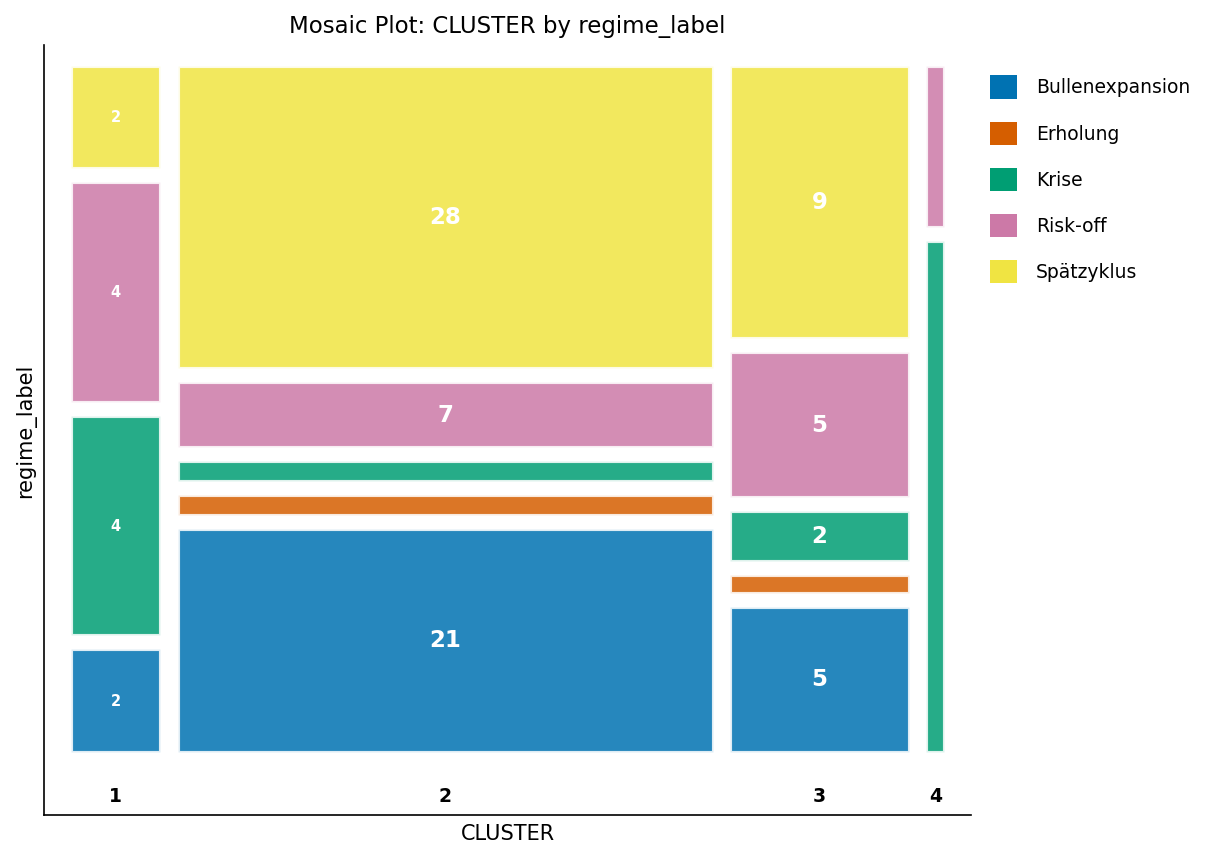

In [7]:
/* --------------------------------------------------------
   Zugewiesene Cluster gegen die bekannten Regime-Labels
   aus der Datengenerierung validieren
   -------------------------------------------------------- */
PROZEDUR HÄUFIGKEITEN DATEN=work.regime_assignments;
    TABLES CLUSTER * regime_label / norow nocol;
    BEZEICHNUNG cluster="Cluster" regime_label="Marktregime";
    TITEL "Regime-Cluster vs. tatsächliches Marktregime";
AUSFÜHREN;

In [8]:
/* --------------------------------------------------------
   Merkmalsmittelwerte je Regime zur Interpretation
   -------------------------------------------------------- */
PROZEDUR MITTELWERTE DATEN=work.regime_assignments mean;
    KLASSE CLUSTER;
    VAR eq_return_pct eq_vol_idx credit_spread_bps
        hy_spread_bps term_spread vix_chg;
    BEZEICHNUNG regime_label="Marktregime" cluster="Cluster"
      eq_return_pct="Aktienrendite (%)" eq_vol_idx="Aktienvolatilität (Index)"
      credit_spread_bps="Credit-Spread (Bp)" hy_spread_bps="High-Yield-Spread (Bp)"
      term_spread="Laufzeit-Spread" vix_chg="VIX-Änderung"
      yield_2y="Rendite 2J" yield_10y="Rendite 10J"
      usd_index_chg="USD-Index-Änderung" commodities_ret="Rohstoffrendite";
AUSFÜHREN;

                                      Regime-Cluster vs. tatsächliches Marktregime                                      

                                                  The MEANS Procedure

                                             Analysis Variable : eq_return_pct Aktienrendite (%)

                                                          N
                                             Cluster    Obs            Mean
                                             ------------------------------
                                             1           12      -2.0955000
                                             2           62      -0.3638871
                                             3           22       0.7421364
                                             4            4      -0.4010000
                                             ------------------------------

                                             Analysis Variable : eq_vol_idx Aktienvolatilität (Index)

             


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### Interpretation

**Kanonische Struktur von ACECLUS.** In der 100-Wochen-Stichprobe konvergierte PROC ACECLUS (P=0.02, Schwellenwert = 2.578941) in zwei Iterationen und erzeugte drei kanonische Variablen. Ihre Eigenwerte von `Inv(ACE)*(COV-ACE)` betragen 0.0219, 0.0093 und 0.0067, also Anteile von 57.8%, 24.4% und 17.8% (kumulativ 100%). Die erste kanonische Achse trägt den dominanten Risk-on/Risk-off-Kontrast; die zweite und dritte verfeinern ihn. Da die Aktienvolatilitäts- und Spread-Merkmale stark gemeinsam variieren, faltet ACECLUS diese gemeinsame Variation in die Innerhalb-Regime-Kovarianz, sodass die kanonischen Achsen eine echte Trennung zwischen den Regimen widerspiegeln statt einer gemeinsamen Skalierung.

**Schwellenwert-Sensitivität.** Ein erneuter Durchlauf bei P=0.05 hebt den Distanz-Schwellenwert auf 2.899704 an, wodurch 4,949 der 4,950 Beobachtungspaare innerhalb der Grenze liegen. Die geschätzte Innerhalb-Regime-Kovarianz entspricht dann nahezu der Gesamtkovarianz, und die kanonische Struktur **reduziert sich auf eine einzige Dimension** (ein Eigenwert, 0.0096, bei 100%). Die Lösungen für P=0.02 und P=0.05 sind hier daher *nicht* austauschbar — ein lockererer Schwellenwert löscht die feineren Regime-Achsen, sodass der engere Schwellenwert die aussagekräftigere Spezifikation für diese Stichprobe ist.

**Clustering auf den kanonischen Variablen.** PROC FASTCLUS (k=4) auf Can1–Can3 ergibt ein Gesamt-R² von 0.5089 und ein Pseudo-F von 33.16. Can2 leistet den Großteil der Trennungsarbeit (R² = 0.626), Can1 trägt mäßig bei (R² = 0.359) und Can3 fügt praktisch nichts hinzu (R² = 0.000) — im Einklang damit, dass nur zwei Achsen ein starkes Signal tragen. Die vier Cluster ordnen sich als Marktstress-Gradient an:

| Cluster | n | Mittlere Aktienrendite | Mittlerer VIX | Mittlerer HY-Spread | Mittlere VIX-Änderung | Deutung |
|---------|---|----------------|----------|----------------|-----------------|---------|
| 2 | 62 | -0.36% | 20.4 | 534 bps | +1.2 | Ruhiger Kern (Bulle / Spätzyklus) |
| 3 | 22 | +0.74% | 20.5 | 539 bps | -9.6 | Erholung, fallende Volatilität |
| 1 | 12 | -2.10% | 39.0 | 720 bps | +11.3 | Erhöhter Stress, Volatilität steigt |
| 4 |  4 | -0.40% | 47.4 | 1,514 bps | +0.1 | Tiefe Krise, extremer Kreditstress |

**Cluster gegenüber wahrem Regime.** Die Kreuztabelle zeigt, dass die Cluster nicht eins zu eins auf die fünf erzeugenden Labels abgebildet werden — erwartungsgemäß, da sich die Labels bei dieser Stichprobengröße im Merkmalsraum stark überlappen. Das große ruhige Cluster (62) absorbiert die meisten Bullen- (21) und Spätzyklus-Wochen (28); das Tiefkrisen-Cluster (4) besteht fast vollständig aus den extremsten Krisenwochen (3 von 4). Die kanonischen Achsen ordnen die Wochen somit nach *Schweregrad* und nicht nach exaktem Label, was das umsetzbarere Signal für die Risikokonditionierung ist.

**Verwendung.** Die exportierten wöchentlichen Zuordnungen unterstützen die taktische Konditionierung: Risiko reduzieren und Duration verlängern, wenn Wochen in Richtung der Cluster 1 und 4 wandern, und Risiko wieder aufbauen, wenn sie in den ruhigen Kern (Cluster 2) oder die Erholungsgruppe (Cluster 3) zurückkehren.


---

In [9]:
/* --------------------------------------------------------
   Wöchentliche Regimezuweisungen für die Konditionierung
   von Portfolio-Risikomodellen und die Signalerzeugung
   exportieren
   -------------------------------------------------------- */
PROZEDUR EXPORT DATEN=work.regime_assignments
    OUTFILE='market_regime_assignments.csv'
    DBMS=csv REPLACE;
AUSFÜHREN;


NOTE: PROC EXPORT data=work.regime_assignments outfile=market_regime_assignments.csv

NOTE: Exported 100 rows to market_regime_assignments.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertraulich
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Bereitgestellt von <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>